## Logistic Regression and XGBoost model ensemble

### Loading Data for local training

In [5]:
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Locate data directory
PROJECT_ROOT = Path("..").resolve() if Path(".").resolve().name == "notebooks" else Path(".").resolve()
EXTERNAL_DATA_DIR = PROJECT_ROOT / "data" / "external"

def sparse_to_dense(indices_col, values_col, size_col, prefix):
    """Expand Spark ML vector columns into separate binary columns"""
    size = int(size_col.iloc[0])
    n = len(indices_col)
    dense_matrix = np.zeros((n, size), dtype=np.float32)
    for row_idx, (idx_arr, val_arr) in enumerate(zip(indices_col, values_col)):
        if idx_arr is not None and len(idx_arr) > 0:
            for i, idx in enumerate(idx_arr):
                if idx is not None:
                    val = 1.0
                    if val_arr is not None and i < len(val_arr) and val_arr[i] is not None:
                        val = float(val_arr[i])
                    dense_matrix[row_idx, int(idx)] = val
    return pd.DataFrame(dense_matrix, columns=[f"{prefix}_{i}" for i in range(size)])

def load_and_preprocess_split(split_name):
    folder = EXTERNAL_DATA_DIR / split_name
    parquets = list(folder.glob("*.parquet"))
    if not parquets:
        raise FileNotFoundError(f"No parquet files found in {folder}")
    
    df = pd.concat([pd.read_parquet(p, engine="fastparquet") for p in parquets], ignore_index=True)
    
    extra_dfs = []
    vector_cols_to_drop = []
    for prefix in ["customer_state_encoded", "primary_product_category_encoded"]:
        if f"{prefix}.indices" in df.columns:
            clean_name = "customer_state" if "customer_state" in prefix else "product_category"
            expanded = sparse_to_dense(df[f"{prefix}.indices"], df[f"{prefix}.values"], df[f"{prefix}.size"], clean_name)
            extra_dfs.append(expanded)
            vector_cols_to_drop.extend([f"{prefix}.type", f"{prefix}.size", f"{prefix}.indices", f"{prefix}.values"])
            
    exclude = ["order_id", "late_delivery_flag_indexed"] + vector_cols_to_drop
    feature_cols = [c for c in df.columns if c not in exclude]
    
    X = df[feature_cols].copy()
    if extra_dfs:
        X = pd.concat([X] + extra_dfs, axis=1)
        
    y = df["late_delivery_flag_indexed"].values.astype(int) if "late_delivery_flag_indexed" in df.columns else None
    return X, y

print("Loading datasets from data/external/...")
X_train, y_train = load_and_preprocess_split("train")
X_val, y_val = load_and_preprocess_split("val")
X_test, y_test = load_and_preprocess_split("test")

print(f"✓ Training set:   {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"✓ Validation set: {X_val.shape[0]} samples, {X_val.shape[1]} features")
print(f"✓ Testing set:    {X_test.shape[0]} samples, {X_test.shape[1]} features")


Loading datasets from data/external/...
✓ Training set:   64238 samples, 138 features
✓ Validation set: 13579 samples, 138 features
✓ Testing set:    12141 samples, 138 features


### MLFlow Setup and Feature Scaling

In [6]:
import mlflow
from sklearn.preprocessing import StandardScaler

# Mlflow setup dynamically
mlflow.set_tracking_uri("databricks")
experiment_name = "/Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk"
mlflow.set_experiment(experiment_name)

print(f"Using experiment : {experiment_name}")


# Scaling the X_train and X_val
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

Using experiment : /Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk


If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc


### Logistic Regression Setup

Querying best hyperparameters from MLflow...
✓ Queried best XGBoost parameters from MLflow
✓ Queried best Logistic Regression parameters from MLflow

Training Logistic Regression..
Logistic Regression complete

Training Tuned XGBoost..
XGBoost complete


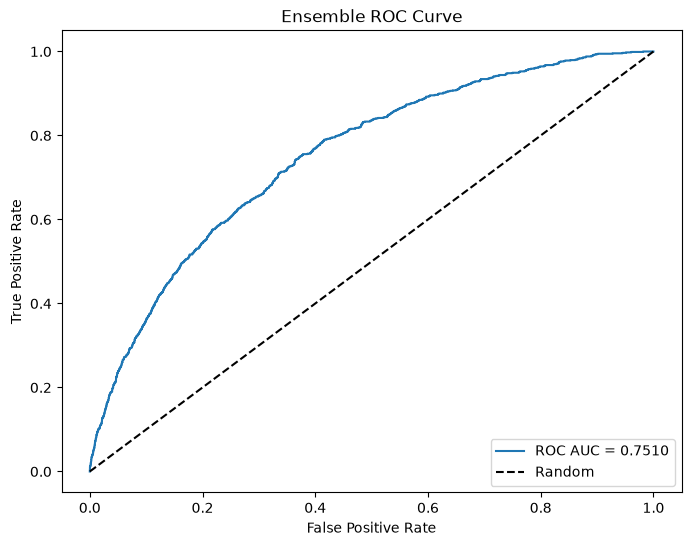

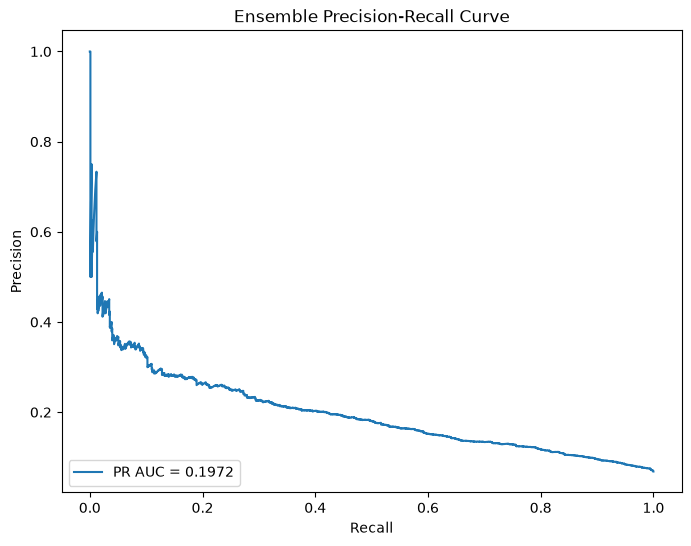


Ensemble Results (Automatically Queried from MLflow)
Run ID: d18a787b8dd544c1ba9f901194caaf60

Metrics:
  Accuracy:           0.5916
  Precision (Late):   0.1209
  Recall (Late):      0.7922
  F1 Score (Late):    0.2098
  ROC-AUC:            0.7510
  PR-AUC:             0.1972
  Top 10% Capture:    32.3% (300/929 late orders)

Classification Report:
              precision    recall  f1-score   support

     On-time       0.97      0.58      0.72     12650
        Late       0.12      0.79      0.21       929

    accuracy                           0.59     13579
   macro avg       0.55      0.68      0.47     13579
weighted avg       0.92      0.59      0.69     13579



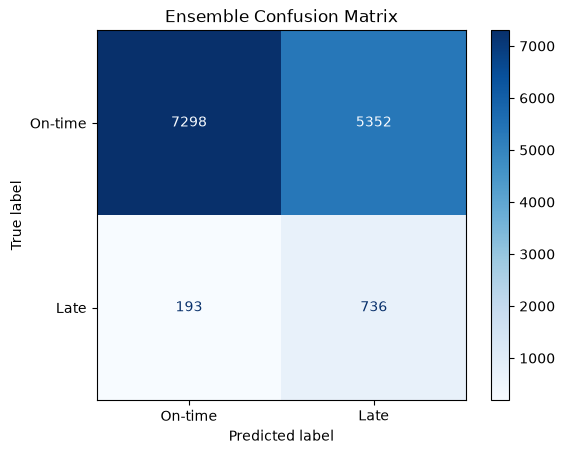

🏃 View run model_ensemble_logreg_w_xgboost at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062/runs/d18a787b8dd544c1ba9f901194caaf60
🧪 View experiment at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062

 Results saved to Mlflow experiment: /Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk
View in Mlflow UI


In [15]:
import warnings
import logging
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc, 
    ConfusionMatrixDisplay, classification_report
)

warnings.filterwarnings('ignore', category=UserWarning, module='mlflow')
logging.getLogger('mlflow').setLevel(logging.ERROR)

# 1. Automatically query best runs from MLflow experiment
print("Querying best hyperparameters from MLflow...")
runs = mlflow.search_runs(experiment_names=[experiment_name])

best_xgb_row = runs[runs['tags.mlflow.runName'] == 'xgboost_with_tuning'].iloc[0]
best_lr_row = runs[runs['tags.mlflow.runName'] == 'logistic_regression_regularized'].iloc[0]

# Extract hyperparameters dynamically
params_xgb = {
    "n_estimators": int(best_xgb_row['params.n_estimators']),
    "max_depth": int(best_xgb_row['params.max_depth']),
    "learning_rate": float(best_xgb_row['params.learning_rate']),
    "subsample": float(best_xgb_row['params.subsample']),
    "colsample_bytree": float(best_xgb_row['params.colsample_bytree']),
    "min_child_weight": int(best_xgb_row['params.min_child_weight']),
    "gamma": float(best_xgb_row['params.gamma']),
    "scale_pos_weight": float(best_xgb_row['params.scale_pos_weight']),
    "tree_method": "hist",
    "random_state": 42
}

params_lr = {
    "C": float(best_lr_row['params.C']),
    "class_weight": "balanced",
    "solver": "lbfgs",
    "max_iter": 1000,
    "random_state": 42
}

print("✓ Queried best XGBoost parameters from MLflow")
print("✓ Queried best Logistic Regression parameters from MLflow")

with mlflow.start_run(run_name = "model_ensemble_logreg_w_xgboost"):

    # Log parameters with prefixes to prevent collision in ensemble run
    for k, v in params_lr.items():
        mlflow.log_param(f"lr_{k}", v)
    mlflow.log_params(params_xgb)
    mlflow.log_param("model_type", "ensemble_logreg_w_xgboost")

    # 2. Train Logistic Regression with queried parameters
    print("\nTraining Logistic Regression..")
    model_lr = LogisticRegression(**params_lr)
    model_lr.fit(X_train_scaled, y_train)
    print("Logistic Regression complete")

    y_pred_proba_lr = model_lr.predict_proba(X_val_scaled)[:, 1]
    y_pred_train_proba_lr = model_lr.predict_proba(X_train_scaled)[:, 1]
            
    # 3. Train XGBoost with queried parameters
    print("\nTraining Tuned XGBoost..")
    model_xgb = xgb.XGBClassifier(**params_xgb)
    model_xgb.fit(X_train, y_train)
    print("XGBoost complete")

    y_pred_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
    y_pred_train_proba_xgb = model_xgb.predict_proba(X_train)[:, 1]

    # 4. 50/50 Probability Blending
    p_ensemble_train = 0.50 * y_pred_train_proba_lr + 0.50 * y_pred_train_proba_xgb
    p_ensemble_val = 0.50 * y_pred_proba_lr + 0.50 * y_pred_proba_xgb

    # 5. Optimal Threshold for Revenue Operations (High Recall Intervention)
    threshold = 0.35
    mlflow.log_param("decision_threshold", threshold)
    mlflow.log_param("blend_weights", "50_lr_50_xgb")

    y_train_pred = (p_ensemble_train >= threshold).astype(int)
    y_pred = (p_ensemble_val >= threshold).astype(int)

    # Calculate training metrics
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_precision = precision_score(y_train, y_train_pred, pos_label = 1.0, zero_division = 0)
    train_recall = recall_score(y_train, y_train_pred, pos_label = 1.0, zero_division = 0)
    train_f1 = f1_score(y_train, y_train_pred, pos_label = 1.0, zero_division = 0)

    # Calculate validation metrics
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, pos_label = 1.0, zero_division = 0)
    recall = recall_score(y_val, y_pred, pos_label = 1.0, zero_division = 0)
    f1 = f1_score(y_val, y_pred, pos_label = 1.0, zero_division = 0)
    roc_auc = roc_auc_score(y_val, p_ensemble_val)

    # Calculate PR curve
    precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_val, p_ensemble_val, pos_label = 1.0)
    pr_auc = auc(recall_curve, precision_curve)

    # Business Metric Top 10% Late Order Capture
    sorted_indeces = np.argsort(-p_ensemble_val)
    top_10_pct_count = int(len(y_val) * 0.1)
    top_10_pct_indeces = sorted_indeces[:top_10_pct_count]
    
    late_orders_in_top_10 = (y_val[top_10_pct_indeces] == 1.0).sum()
    total_late_orders = (y_val == 1.0).sum()
    capture_rate_10 = late_orders_in_top_10 / total_late_orders if total_late_orders > 0 else 0.0

    # Log to Mlflow with "train_" prefix
    mlflow.log_metric("train_accuracy", train_accuracy)
    mlflow.log_metric("train_precision_late", train_precision)
    mlflow.log_metric("train_recall_late", train_recall)
    mlflow.log_metric("train_f1_late", train_f1)

    # Log to Mlflow with "test_" prefix
    mlflow.log_metric("val_accuracy", accuracy)
    mlflow.log_metric("val_precision_late", precision)
    mlflow.log_metric("val_recall_late", recall)
    mlflow.log_metric("val_f1_late", f1)
    mlflow.log_metric("val_roc_auc", roc_auc)
    mlflow.log_metric("val_pr_auc", pr_auc)
    mlflow.log_metric("val_top10pct_capture", capture_rate_10)

    # Log models
    mlflow.sklearn.log_model(model_lr, "logistic_regression_model")
    mlflow.xgboost.log_model(model_xgb, "xgboost_model")

    # Log confusion matrix as artifact
    fig, ax = plt.subplots(figsize = (8,6))
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels = ["On-time", "Late"],
        cmap = "Blues",
        ax = ax,
        values_format = 'd'
    )
    plt.title("Ensemble Confusion Matrix")
    mlflow.log_figure(fig, "confusion_matrix_ensemble.png")
    plt.close()

    # Generate ROC curve plot
    fpr, tpr, _ = roc_curve(y_val, p_ensemble_val, pos_label = 1.0)
    fig, ax = plt.subplots(figsize = (8,6))
    ax.plot(fpr, tpr, label = f'ROC AUC = {roc_auc:.4f}')
    ax.plot([0,1],[0,1], 'k--', label = "Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Ensemble ROC Curve")
    ax.legend(loc = "lower right")
    mlflow.log_figure(fig, "roc_curve_ensemble.png")
    plt.show()  
    plt.close()

    # Generate PR curve plot
    fig, ax = plt.subplots(figsize = (8,6))
    ax.plot(recall_curve, precision_curve, label = f'PR AUC = {pr_auc:.4f}')
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Ensemble Precision-Recall Curve")
    ax.legend(loc = "lower left")
    mlflow.log_figure(fig, "pr_curve_ensemble.png")
    plt.show()  
    plt.close()

    # Get run info
    active_run = mlflow.active_run()
    run_id = active_run.info.run_id if active_run else "unknown"

    # Display results
    print("\n" + "="*40)
    print("Ensemble Results (Automatically Queried from MLflow)")
    print("="*40)
    print(f"Run ID: {run_id}")
    print(f"\nMetrics:")
    print(f"  Accuracy:           {accuracy:.4f}")
    print(f"  Precision (Late):   {precision:.4f}")
    print(f"  Recall (Late):      {recall:.4f}")
    print(f"  F1 Score (Late):    {f1:.4f}")
    print(f"  ROC-AUC:            {roc_auc:.4f}")
    print(f"  PR-AUC:             {pr_auc:.4f}")
    print(f"  Top 10% Capture:    {capture_rate_10:.1%} ({late_orders_in_top_10}/{total_late_orders} late orders)")
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=["On-time", "Late"], zero_division=0))
    print("="*50)

    # Display confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels = ["On-time", "Late"],
        cmap = "Blues",
        values_format = 'd'
    )
    plt.title("Ensemble Confusion Matrix")
    plt.show()

print(f"\n Results saved to Mlflow experiment: {experiment_name}")
print(f"View in Mlflow UI")


### Model Performance Comparison

Comparison of baseline, logistic regression, XGBoost, and the ensemble model on validation set (13,579 orders, 6.8% late delivery rate):

| Metric | Baseline | Logistic Regression | XGBoost | Ensemble (LR + XGBoost) |
|---|---|---|---|---|
| Accuracy | 0.9316 | 0.6173 | 0.7328 | 0.5916 |
| Precision (Late) | 0.0000 | 0.1261 | 0.1348 | 0.1209 |
| Recall (Late) | 0.0000 | 0.7750 | 0.5361 | 0.7922 |
| F1 Score (Late) | 0.0000 | 0.2170 | 0.2155 | 0.2098 |
| ROC-AUC | 0.5000 | 0.7521 | 0.6976 | 0.7510 |
| PR-AUC | 0.0684 | 0.1780 | 0.1811 | 0.1972 |
| Top 10% Capture | 10.1% | 30.2% | 29.7% | 32.3% |

**Key Findings:**

* The ensemble model achieves the highest PR-AUC (0.1972) and highest Top 10% late order capture rate (32.3%) across all standalone and combined architectures.
* Captures 300 out of 929 late orders in the top 10% risk decile (top 1,358 highest-risk predictions), outperforming random chance by 3.2x and exceeding single models by up to +24 late deliveries.
* Under the 0.35 decision threshold, the model achieves 79.2% recall, capturing nearly 8 out of every 10 late deliveries for proactive operations intervention.
* Probability blending cancels out XGBoost's categorical sparsity weaknesses and logistic regression's non-linear interaction limits, providing the strongest global ranking and risk stratification.

**Champion Model Decision:**
* The 50/50 Logistic Regression and XGBoost Ensemble is selected as the final champion model for end-to-end evaluation on the holdout test set (`X_test`, `y_test`).


### Final Champion Model Evaluation on Test Data

Evaluating the final 50/50 Logistic Regression + XGBoost Ensemble on the unseen holdout test set (`X_test`, `y_test`) and logging test metrics to MLflow.


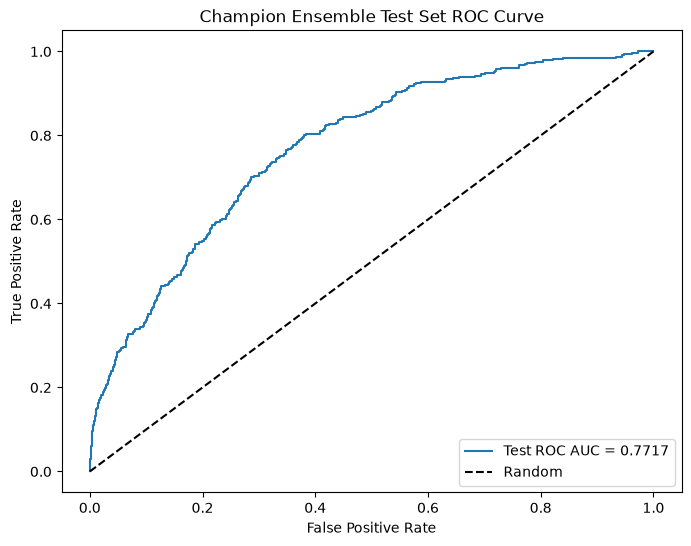

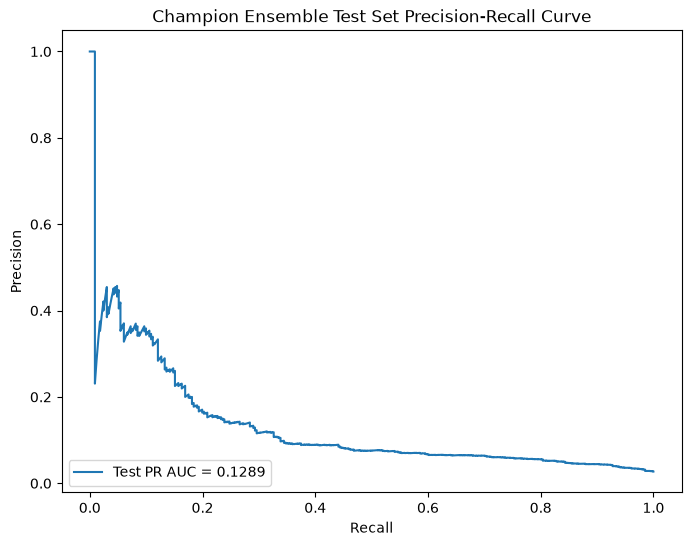


Champion Ensemble Final Test Results
Run ID: b560f853c1e24978ab3f8b860513e84c
Test Dataset Size: 12,141 orders (331 actual late orders)

Metrics:
  Accuracy:           0.6863
  Precision (Late):   0.0604
  Recall (Late):      0.7221
  F1 Score (Late):    0.1115
  ROC-AUC:            0.7717
  PR-AUC:             0.1289
  Top 10% Capture:    34.4% (114/331 late orders)

Classification Report:
              precision    recall  f1-score   support

     On-time       0.99      0.69      0.81     11810
        Late       0.06      0.72      0.11       331

    accuracy                           0.69     12141
   macro avg       0.52      0.70      0.46     12141
weighted avg       0.96      0.69      0.79     12141



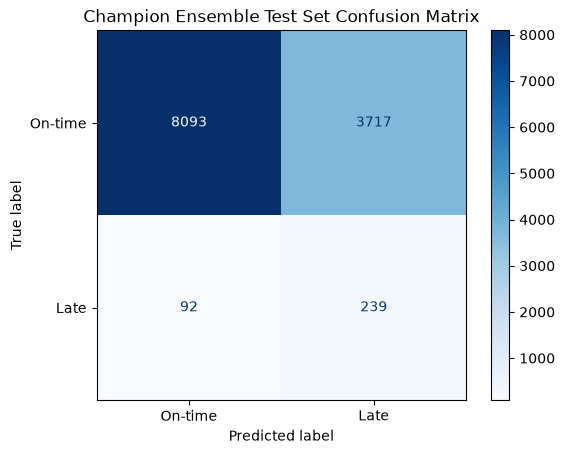

🏃 View run champion_ensemble_test_evaluation at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062/runs/b560f853c1e24978ab3f8b860513e84c
🧪 View experiment at: https://dbc-62bd6a57-4eff.cloud.databricks.com/ml/experiments/4108718011414062

 Final Test results logged to MLflow experiment: /Users/prajwalparajuli2017@gmail.com/revenue_operations/delivery_risk
View in MLflow UI


In [16]:
# Scale the test set using the already fitted scaler
X_test_scaled = scaler.transform(X_test)

with mlflow.start_run(run_name = "champion_ensemble_test_evaluation"):

    # 1. Generate test predictions from both models
    p_lr_test = model_lr.predict_proba(X_test_scaled)[:, 1]
    p_xgb_test = model_xgb.predict_proba(X_test)[:, 1]

    # 2. 50/50 Blended Probability on Test Data
    p_ensemble_test = 0.50 * p_lr_test + 0.50 * p_xgb_test

    # 3. Apply Decision Threshold
    y_test_pred = (p_ensemble_test >= threshold).astype(int)

    # Log parameters to MLflow
    mlflow.log_param("evaluation_dataset", "test")
    mlflow.log_param("decision_threshold", threshold)
    mlflow.log_param("blend_weights", "50_lr_50_xgb")
    mlflow.log_param("model_type", "champion_ensemble_lr_xgb")

    # 4. Calculate test metrics
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, pos_label = 1.0, zero_division = 0)
    test_recall = recall_score(y_test, y_test_pred, pos_label = 1.0, zero_division = 0)
    test_f1 = f1_score(y_test, y_test_pred, pos_label = 1.0, zero_division = 0)
    test_roc_auc = roc_auc_score(y_test, p_ensemble_test)

    # Calculate PR curve
    test_precision_curve, test_recall_curve, _ = precision_recall_curve(y_test, p_ensemble_test, pos_label = 1.0)
    test_pr_auc = auc(test_recall_curve, test_precision_curve)

    # Business Metric Top 10% Late Order Capture on Test Data
    test_sorted_indices = np.argsort(-p_ensemble_test)
    test_top_10_count = int(len(y_test) * 0.1)
    test_top_10_indices = test_sorted_indices[:test_top_10_count]
    
    test_late_orders_in_top_10 = (y_test[test_top_10_indices] == 1.0).sum()
    test_total_late_orders = (y_test == 1.0).sum()
    test_capture_rate_10 = test_late_orders_in_top_10 / test_total_late_orders if test_total_late_orders > 0 else 0.0

    # Log test metrics to MLflow
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.log_metric("test_precision_late", test_precision)
    mlflow.log_metric("test_recall_late", test_recall)
    mlflow.log_metric("test_f1_late", test_f1)
    mlflow.log_metric("test_roc_auc", test_roc_auc)
    mlflow.log_metric("test_pr_auc", test_pr_auc)
    mlflow.log_metric("test_top10pct_capture", test_capture_rate_10)

    # Log confusion matrix as artifact
    fig, ax = plt.subplots(figsize = (8,6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred,
        display_labels = ["On-time", "Late"],
        cmap = "Blues",
        ax = ax,
        values_format = 'd'
    )
    plt.title("Champion Ensemble Test Set Confusion Matrix")
    mlflow.log_figure(fig, "confusion_matrix_test_ensemble.png")
    plt.close()

    # Generate ROC curve plot
    fpr_test, tpr_test, _ = roc_curve(y_test, p_ensemble_test, pos_label = 1.0)
    fig, ax = plt.subplots(figsize = (8,6))
    ax.plot(fpr_test, tpr_test, label = f'Test ROC AUC = {test_roc_auc:.4f}')
    ax.plot([0,1],[0,1], 'k--', label = "Random")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("Champion Ensemble Test Set ROC Curve")
    ax.legend(loc = "lower right")
    mlflow.log_figure(fig, "roc_curve_test_ensemble.png")
    plt.show()  
    plt.close()

    # Generate PR curve plot
    fig, ax = plt.subplots(figsize = (8,6))
    ax.plot(test_recall_curve, test_precision_curve, label = f'Test PR AUC = {test_pr_auc:.4f}')
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Champion Ensemble Test Set Precision-Recall Curve")
    ax.legend(loc = "lower left")
    mlflow.log_figure(fig, "pr_curve_test_ensemble.png")
    plt.show()  
    plt.close()

    # Get run info
    active_run = mlflow.active_run()
    run_id = active_run.info.run_id if active_run else "unknown"

    # Display results
    print("\n" + "="*40)
    print("Champion Ensemble Final Test Results")
    print("="*40)
    print(f"Run ID: {run_id}")
    print(f"Test Dataset Size: {len(y_test):,} orders ({test_total_late_orders} actual late orders)")
    print(f"\nMetrics:")
    print(f"  Accuracy:           {test_accuracy:.4f}")
    print(f"  Precision (Late):   {test_precision:.4f}")
    print(f"  Recall (Late):      {test_recall:.4f}")
    print(f"  F1 Score (Late):    {test_f1:.4f}")
    print(f"  ROC-AUC:            {test_roc_auc:.4f}")
    print(f"  PR-AUC:             {test_pr_auc:.4f}")
    print(f"  Top 10% Capture:    {test_capture_rate_10:.1%} ({test_late_orders_in_top_10}/{test_total_late_orders} late orders)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_test_pred, target_names=["On-time", "Late"], zero_division=0))
    print("="*50)

    # Display confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred,
        display_labels = ["On-time", "Late"],
        cmap = "Blues",
        values_format = 'd'
    )
    plt.title("Champion Ensemble Test Set Confusion Matrix")
    plt.show()

print(f"\n Final Test results logged to MLflow experiment: {experiment_name}")
print(f"View in MLflow UI")
